# Description - Exploration of NBS Results

This notebook takes the outputs from running NBS and plots then for interpretation. It was used to generate the Circos plots of interest for NBS models

In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import pandas as pd
import numpy as np
import os.path as osp
import hvplot.pandas
from utils.basics import FB_400ROI_ATLAS_NAME as ATLAS_NAME
from utils.basics import ATLASES_DIR, RESOURCES_NIMARE_DIR, RESOURCES_CONN_DIR, RESOURCES_NBS_DIR
from utils.plotting import hvplot_fc, hvplot_fc_nwlevel, create_graph_from_matrix, plot_as_graph
import holoviews as hv
from holoviews import opts
from IPython import display
import panel as pn
import matplotlib.pyplot as plt
from nilearn.plotting import plot_connectome
from matplotlib.colors import LinearSegmentedColormap
from sklearn.preprocessing import MinMaxScaler
from nilearn.image import load_img
from nilearn import masking

/data/SFIMJGC_HCP7T/Apps/envs/fc_introspection_2023b_py310/lib/python3.10/site-packages/nxviz/__init__.py:18: UserWarning: 
nxviz has a new API! Version 0.7.4 onwards, the old class-based API is being
deprecated in favour of a new API focused on advancing a grammar of network
graphics. If your plotting code depends on the old API, please consider
pinning nxviz at version 0.7.4, as the new API will break your old code.

To check out the new API, please head over to the docs at
https://ericmjl.github.io/nxviz/ to learn more. We hope you enjoy using it!

(This deprecation message will go away in version 1.0.)

  warnings.warn(


In [2]:
NBS_CONTRASTS = ['SetA_gt_SetB','SetB_gt_SetA']

# 2. Load information about the Atlas and ROI needed for plotting

Load the data structure with information about the ROIs in the atlas

In [3]:
ATLASINFO_PATH = osp.join(ATLASES_DIR,ATLAS_NAME,'{ATLAS_NAME}.roi_info.csv'.format(ATLAS_NAME=ATLAS_NAME))
roi_info       = pd.read_csv(ATLASINFO_PATH)
Nrois          = roi_info.shape[0]
Nedges         = int(Nrois*(Nrois-1)/2)
print(Nrois,Nedges)

380 72010


In [13]:
roi_info[roi_info['ROI_Name']=='LH_SalVentAttn_Med_5']

,ROI_ID,Hemisphere,Network,ROI_Name,pos_R,pos_A,pos_S,color_R,color_G,color_B,RGB
110,111,LH,SalVentAttn,LH_SalVentAttn_Med_5,-12,-42,48,197,58,253,#c53afd


Count the number of networks and get their names

In [4]:
networks = list(roi_info['Network'].unique())
print(networks, len(networks))

['Vis', 'SomMot', 'DorsAttn', 'SalVentAttn', 'Limbic', 'Cont', 'Default', 'Subcortical'] 8


Load the connections that are significantly stronger for the contrast: $$Image-Pos-Others > Surr-Neg-Self$$
and the contrast: $$Surr-Neg-Self > Image-Pos-Others$$

In [6]:
data = {}
for contrast in NBS_CONTRASTS:
    aux_path = osp.join(RESOURCES_NBS_DIR,ATLAS_NAME,f'NBS_Results',f'NBS_{contrast}.edge')
    if osp.exists(aux_path):
        aux_data = np.loadtxt(aux_path)
        data[contrast]  = pd.DataFrame(aux_data,
                                         index   = roi_info.set_index(['Hemisphere','Network','ROI_Name','ROI_ID','RGB']).index, 
                                         columns = roi_info.set_index(['Hemisphere','Network','ROI_Name','ROI_ID','RGB']).index)
        print('++ INFO: Data available for %s' % contrast)
    else:
        data[contrast] = pd.DataFrame(np.zeros((Nrois,Nrois)),
                                     index   = roi_info.set_index(['Hemisphere','Network','ROI_Name','ROI_ID','RGB']).index, 
                                     columns = roi_info.set_index(['Hemisphere','Network','ROI_Name','ROI_ID','RGB']).index)
        print('++ WARTNING: No results available for %s' % contrast)

++ INFO: Data available for SetA_gt_SetB
++ WARTNING: No results available for SetB_gt_SetA


In [ ]:
N_sig_edges = data['SetA_gt_SetB'].sum().sum()/2
PC_sig_edges = 100 * N_sig_edges / Nedges
N_sig_edges,PC_sig_edges


(458.0, 0.6360227746146369)

In [29]:
N_sig_nodes  = (data['SetA_gt_SetB'].sum() > 0).sum()
PC_sig_nodes = 100 * N_sig_nodes / N_sig_nodes
N_sig_nodes,PC_sig_nodes

(210, 100.0)

In [9]:
data['Both'] = data['SetA_gt_SetB'] - data['SetB_gt_SetA']

We will also write the results of NBS into text format that we can load into CONN to generate the brain views of the results

In [11]:
RESOURCES_CONN_DIR

'/data/SFIMJGC_Introspec/2023_fc_introspection/code/fc_introspection/resources/conn'

In [12]:
for contrast in data.keys():
    if data[contrast] is not None:
        aux_path = osp.join(RESOURCES_CONN_DIR,f'NBS_{contrast}.txt')
        np.savetxt(aux_path,data[contrast].values)
        print("++ INFO: Contrast data [%s] saved to disk %s" %(contrast,aux_path))

++ INFO: Contrast data [SetA_gt_SetB] saved to disk /data/SFIMJGC_Introspec/2023_fc_introspection/code/fc_introspection/resources/conn/NBS_SetA_gt_SetB.txt
++ INFO: Contrast data [SetB_gt_SetA] saved to disk /data/SFIMJGC_Introspec/2023_fc_introspection/code/fc_introspection/resources/conn/NBS_SetB_gt_SetA.txt
++ INFO: Contrast data [Both] saved to disk /data/SFIMJGC_Introspec/2023_fc_introspection/code/fc_introspection/resources/conn/NBS_Both.txt


# Plot results at the individual connection level

In [16]:
hvplot_fc(data['Both'].loc[:,networks,:].T.loc[:,networks,:].T, by='Network', add_color_segments=True, add_labels=True, cmap=['#ED7D31','#ffffff', '#4472C4'], major_label_overrides={-0.5:'Set B > Set A',0:'',0.5:'Set A > Set B'}, colorbar_position='top').opts(toolbar=None, title='Both')

:Overlay
   .HeatMap.I   :HeatMap   [columns,index]   (value)
   .HLine.I     :HLine   [x,y]
   .VLine.I     :VLine   [x,y]
   .HLine.II    :HLine   [x,y]
   .VLine.II    :VLine   [x,y]
   .HLine.III   :HLine   [x,y]
   .VLine.III   :VLine   [x,y]
   .HLine.IV    :HLine   [x,y]
   .VLine.IV    :VLine   [x,y]
   .HLine.V     :HLine   [x,y]
   .VLine.V     :VLine   [x,y]
   .HLine.VI    :HLine   [x,y]
   .VLine.VI    :VLine   [x,y]
   .HLine.VII   :HLine   [x,y]
   .VLine.VII   :VLine   [x,y]
   .HLine.VIII  :HLine   [x,y]
   .VLine.VIII  :VLine   [x,y]
   .HLine.IX    :HLine   [x,y]
   .VLine.IX    :VLine   [x,y]
   .HLine.X     :HLine   [x,y]
   .VLine.X     :VLine   [x,y]
   .HLine.XI    :HLine   [x,y]
   .VLine.XI    :VLine   [x,y]
   .Segments.I  :Segments   [x0,y0,x1,y1]   (Networks)
   .Segments.II :Segments   [x0,y0,x1,y1]   (Networks)

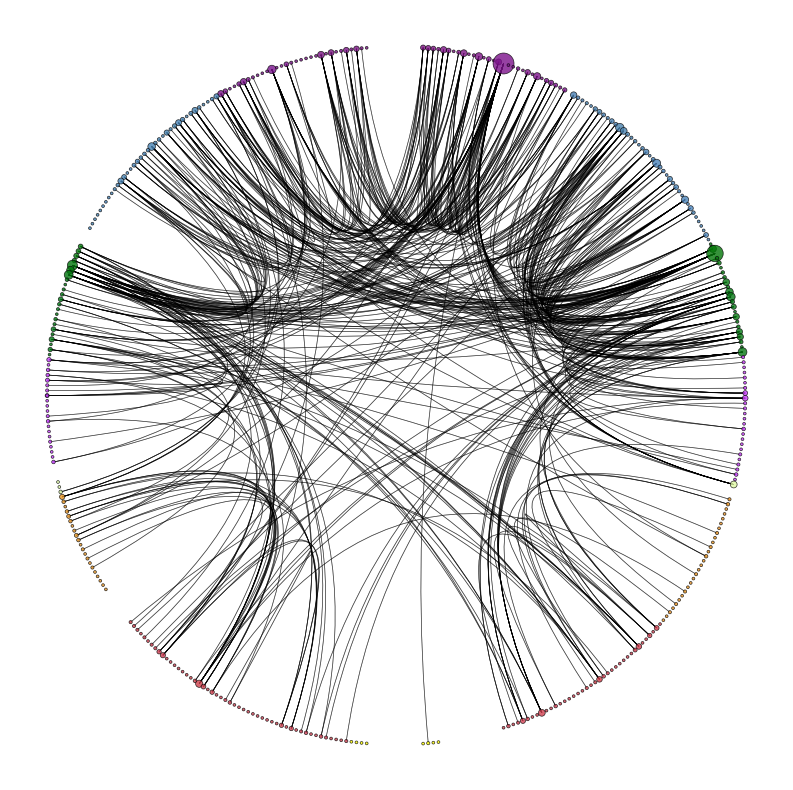

In [17]:
plot_as_graph(data['SetA_gt_SetB'], edge_weight=.5, show_hemi_labels=False,pos_edges_color='k')

In [18]:
data['SetA_gt_SetB'].sum(axis=1).sort_values(ascending=False)

Hemisphere  Network   ROI_Name            ROI_ID  RGB    
RH          Vis       RH_Vis_17           208     #7c128b    45.0
            DorsAttn  RH_DorsAttn_Post_3  264     #047709    34.0
LH          DorsAttn  LH_DorsAttn_Post_5  73      #00760b    18.0
                      LH_DorsAttn_Post_7  75      #00760d    15.0
RH          DorsAttn  RH_DorsAttn_PrCv_1  284     #057612    15.0
                                                             ... 
LH          Vis       LH_Vis_22           22      #781386     0.0
                      LH_Vis_23           23      #781387     0.0
                      LH_Vis_28           28      #78138c     0.0
                      LH_Vis_29           29      #78138d     0.0
            SomMot    LH_SomMot_3         34      #4681ad     0.0
Length: 380, dtype: float64

In [19]:
hvplot_fc_nwlevel(data['SetA_gt_SetB'], title='', add_net_colors=True, add_net_labels='both', mode='count', cmap='Greys', clim_max=100, labels_text_color='Greys_r').opts(toolbar=None)

:Overlay
   .HeatMap.I   :HeatMap   [columns,index]   (value)
   .Labels.I    :Labels   [x,y]   (NConns)
   .Segments.I  :Segments   [x0,y0,x1,y1]   (Networks)
   .Segments.II :Segments   [x0,y0,x1,y1]   (Networks)

In [14]:
hvplot_fc_nwlevel(data['Image-Pos-Others_gt_Surr-Neg-Self'], title='', add_net_colors=True, add_net_labels='y', mode='count', cmap='Reds', clim_max=30, labels_text_color='Reds_r').opts(toolbar=None)

:Overlay
   .HeatMap.I   :HeatMap   [columns,index]   (value)
   .Labels.I    :Labels   [x,y]   (NConns)
   .Segments.I  :Segments   [x0,y0,x1,y1]   (Networks)
   .Segments.II :Segments   [x0,y0,x1,y1]   (Networks)

# Laterality Index for each contrast


In [20]:
aux         = (data['SetA_gt_SetB']).copy()
aux.index   = data['SetA_gt_SetB'].index.get_level_values('Hemisphere')
aux.columns = data['SetA_gt_SetB'].columns.get_level_values('Hemisphere')
f2GTf1_LL   = (aux.loc['LH','LH'].sum().sum() / 2)
f2GTf1_RR   = (aux.loc['RH','RH'].sum().sum() / 2)
f2GTf1_LR   = aux.loc['LH','RH'].sum().sum()
print('++ INFO [SetA > SetB] L-L Conns: %d' % f2GTf1_LL)
print('++ INFO [SetA > SetB] R-R Conns: %d' % f2GTf1_RR)
print('++ INFO [SetA > SetB] R-L Conns: %d' % f2GTf1_LR)
print('++ --------------------------------------------------------')
f2GTf1_fcLI  = (f2GTf1_LL - f2GTf1_RR) / (f2GTf1_LL + f2GTf1_RR)
print('++ INFO [SetA > SetB] fcLI:      %.2f' % f2GTf1_fcLI)

++ INFO [SetA > SetB] L-L Conns: 88
++ INFO [SetA > SetB] R-R Conns: 169
++ INFO [SetA > SetB] R-L Conns: 201
++ --------------------------------------------------------
++ INFO [SetA > SetB] fcLI:      -0.32
